In [1]:
# =========================
# 1) SETUP
# =========================
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

print("Ready.")


Ready.


In [2]:
df = pd.read_csv("/content/symile_mimic_data.csv")
print(df.shape)
df.head()

(11027, 94)


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,race,hospital_expire_flag,gender,anchor_age,anchor_year,dod,admittime_year,age,cxr_24_72_hr,cxr_dicom_id,cxr_study_id,cxr_ViewPosition,cxr_ViewCodeSequence_CodeMeaning,cxr_StudyDateTime,cxr_path,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,ecg_adm,ecg_study_id,ecg_file_name,ecg_time,ecg_path,51221,51265,50912,50971,51222,51301,51249,51279,51250,51248,51277,51006,50983,50902,50882,50868,50931,50960,50893,50970,51237,51274,51275,51146,51256,51254,51200,51244,52172,50934,51678,50947,50861,50878,50813,50863,50885,50820,50862,50802,50821,50804,50818,52075,52073,52074,52069,51133,50910,52135,labs_all_nan
0,10001176,23334588,2186-11-29 03:56:00,2186-12-02 15:00:00,NaN,EU OBSERVATION,EMERGENCY ROOM,NaN,WHITE,0,F,64,2186,NaN,2186,64,3b8b1b7d-054490d5-385641e7-ff43d2c8-9505f058,3b8b1b7d-054490d5-385641e7-ff43d2c8-9505f058,54684191.0,PA,postero-anterior,2186-12-01 15:26:02,files/p10/p10001176/s54684191/3b8b1b7d-054490d...,54684191.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40925049.0,40925049.0,40925049.0,2186-11-28 23:16:00,files/p1000/p10001176/s40925049/40925049,35.4,206.0,0.7,3.9,11.5,7.2,32.3,4.11,86.0,27.8,15.5,14.0,136.0,98.0,28.0,14.0,119.0,NaN,NaN,NaN,NaN,NaN,NaN,0.4,81.1,6.9,0.8,10.8,NaN,NaN,NaN,NaN,54.0,50.0,2.0,64.0,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,10001401,24818636,2131-07-30 21:40:00,2131-08-04 14:10:00,NaN,OBSERVATION ADMIT,EMERGENCY ROOM,SKILLED NURSING FACILITY,WHITE,0,F,89,2131,NaN,2131,89,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604.0,PA,postero-anterior,2131-08-02 11:45:59,files/p10/p10001401/s55350604/d9db838d-4612fd1...,55350604.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49368993.0,49368993.0,49368993.0,2131-07-30 13:04:00,files/p1000/p10001401/s49368993/49368993,29.1,479.0,0.7,4.1,9.0,7.7,30.9,3.07,95.0,29.3,14.9,22.0,136.0,98.0,22.0,20.0,101.0,NaN,NaN,NaN,1.1,12.4,33.4,0.7,64.9,11.6,0.7,20.7,52.1,7.0,66.0,0.0,8.0,10.0,NaN,51.0,0.2,NaN,NaN,NaN,NaN,NaN,NaN,4.97,0.05,0.89,0.05,1.58,NaN,1.4,0.0
2,10001884,26184834,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-20 05:15:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,BLACK/AFRICAN AMERICAN,1,F,68,2122,2131-01-20,2131,77,9fd47edd-07087209-b901811e-3e9e5f50-f382f611,9fd47edd-07087209-b901811e-3e9e5f50-f382f611,57156853.0,AP,antero-posterior,2131-01-10 12:54:30,files/p10/p10001884/s57156853/9fd47edd-0708720...,57156853.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45886398.0,45886398.0,45886398.0,2131-01-07 13:48:00,files/p1000/p10001884/s45886398/45886398,38.6,216.0,1.1,3.5,12.3,7.5,31.9,4.39,88.0,28.0,18.0,20.0,135.0,91.0,29.0,19.0,143.0,2.0,10.3,3.6,NaN,NaN,NaN,0.0,92.1,3.5,0.0,3.9,56.9,NaN,NaN,NaN,50.0,41.0,3.0,73.0,0.3,7.42,4.4,2.0,130.0,28.0,41.0,6.91,0.00,0.26,0.00,0.29,NaN,0.5,0.0
3,10002013,23581541,2160-05-18 07:45:00,2160-05-23 13:30:00,NaN,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,OTHER,0,F,53,2156,NaN,2160,57,48edbd44-ca2376ca-059a9f55-3fc8abd1-e13e4b76,48edbd44-ca2376ca-059a9f55-3fc8abd1-e13e4b76,57741292.0,AP,antero-posterior,2160-05-20 12:55:05,files/p10/p10002013/s57741292/48edbd44-ca2376c...,57741292.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,47723981.0,47723981.0,47723981.0,2160-05-18 15:10:00,files/p1000/p10002013/s47723981/47723981,28.6,252.0,1.1,4.0,10.2,18.2,35.7,2.95,97.0,34.8,13.0,16.0,140.0,109.0,23.0,12.0,98.0,2.1,NaN,NaN,1.2,12.7,25.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.3,NaN,NaN,7.33,NaN,0.0,441.0,27.0,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,10002428,23473524,2156-05-11 14:49:00,2156-05-22 14:16:00,NaN,EW EMER.,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,WHITE,0,F,80,2155,NaN,2156,81,d999236f-95dcb8b7-a4d20a3f-be538f50-ce13a08e,d999

In [3]:

df.info()
df.describe(include="all").T.head(30)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11027 entries, 0 to 11026
Data columns (total 94 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   subject_id                        11027 non-null  int64  
 1   hadm_id                           11027 non-null  int64  
 2   admittime                         11027 non-null  object 
 3   dischtime                         11027 non-null  object 
 4   deathtime                         1011 non-null   object 
 5   admission_type                    11027 non-null  object 
 6   admission_location                11027 non-null  object 
 7   discharge_location                10511 non-null  object 
 8   race                              11027 non-null  object 
 9   hospital_expire_flag              11027 non-null  int64  
 10  gender                            11027 non-null  object 
 11  anchor_age                        11027 non-null  int64  
 12  anch

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject_id,11027.0,NaN,NaN,NaN,14779551.968622,2716019.206137,10001176.0,12450775.0,14785071.0,17132490.0,19509569.0
hadm_id,11027.0,NaN,NaN,NaN,25034784.91013,2882497.787715,20001305.0,22539724.5,25068720.0,27526878.0,29999670.0
admittime,11027,11024,2170-12-19 07:15:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dischtime,11027,11020,2132-09-24 15:30:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deathtime,1011,1011,2147-05-11 16:50:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type,11027,9,EW EMER.,7122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_location,11027,8,EMERGENCY ROOM,8461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discharge_location,10511,13,HOME HEALTH CARE,2734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,11027,33,WHITE,6968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hospital_expire_flag,11027.0,NaN,NaN,NaN,0.091956,0.288977,0.0,0.0,0.0,0.0,1.0


In [4]:
# Columns that are not analytically useful for DS-600
drop_cols = [
    "subject_id",
    "hadm_id",
    "cxr_24_72rf_hr",
    "cxr_dicom_id",
    "cxr_study_id",
    "study_id",
    "cxr_path",
    "ecg_path",
    "ecg_file_name",
    "ecg_study_id",
    "ecg_adm",
    "cxr_StudyDateTime",
    "ecg_time",
    "anchor_year",
    "admittime_year",
    "dod",
    "deathtime"
]

drop_cols = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=drop_cols)

print("Remaining shape:", df.shape)
df.head()


Remaining shape: (11027, 77)


,admittime,dischtime,admission_type,admission_location,discharge_location,race,hospital_expire_flag,gender,anchor_age,age,cxr_ViewPosition,cxr_ViewCodeSequence_CodeMeaning,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,51221,51265,50912,50971,51222,51301,51249,51279,51250,51248,51277,51006,50983,50902,50882,50868,50931,50960,50893,50970,51237,51274,51275,51146,51256,51254,51200,51244,52172,50934,51678,50947,50861,50878,50813,50863,50885,50820,50862,50802,50821,50804,50818,52075,52073,52074,52069,51133,50910,52135,labs_all_nan
0,2186-11-29 03:56:00,2186-12-02 15:00:00,EU OBSERVATION,EMERGENCY ROOM,NaN,WHITE,0,F,64,64,PA,postero-anterior,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.4,206.0,0.7,3.9,11.5,7.2,32.3,4.11,86.0,27.8,15.5,14.0,136.0,98.0,28.0,14.0,119.0,NaN,NaN,NaN,NaN,NaN,NaN,0.4,81.1,6.9,0.8,10.8,NaN,NaN,NaN,NaN,54.0,50.0,2.0,64.0,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2131-07-30 21:40:00,2131-08-04 14:10:00,OBSERVATION ADMIT,EMERGENCY ROOM,SKILLED NURSING FACILITY,WHITE,0,F,89,89,PA,postero-anterior,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.1,479.0,0.7,4.1,9.0,7.7,30.9,3.07,95.0,29.3,14.9,22.0,136.0,98.0,22.0,20.0,101.0,NaN,NaN,NaN,1.1,12.4,33.4,0.7,64.9,11.6,0.7,20.7,52.1,7.0,66.0,0.0,8.0,10.0,NaN,51.0,0.2,NaN,NaN,NaN,NaN,NaN,NaN,4.97,0.05,0.89,0.05,1.58,NaN,1.4,0.0
2,2131-01-07 20:39:00,2131-01-20 05:15:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,BLACK/AFRICAN AMERICAN,1,F,68,77,AP,antero-posterior,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.6,216.0,1.1,3.5,12.3,7.5,31.9,4.39,88.0,28.0,18.0,20.0,135.0,91.0,29.0,19.0,143.0,2.0,10.3,3.6,NaN,NaN,NaN,0.0,92.1,3.5,0.0,3.9,56.9,NaN,NaN,NaN,50.0,41.0,3.0,73.0,0.3,7.42,4.4,2.0,130.0,28.0,41.0,6.91,0.00,0.26,0.00,0.29,NaN,0.5,0.0
3,2160-05-18 07:45:00,2160-05-23 13:30:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,OTHER,0,F,53,57,AP,antero-posterior,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,28.6,252.0,1.1,4.0,10.2,18.2,35.7,2.95,97.0,34.8,13.0,16.0,140.0,109.0,23.0,12.0,98.0,2.1,NaN,NaN,1.2,12.7,25.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.3,NaN,NaN,7.33,NaN,0.0,441.0,27.0,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2156-05-11 14:49:00,2156-05-22 14:16:00,EW EMER.,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,WHITE,0,F,80,81,AP,antero-posterior,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,29.0,323.0,0.3,3.1,8.4,16.0,29.1,2.84,102.0,29.7,16.4,18.0,135.0,107.0,23.0,8.0,96.0,1.8,8.1,3.2,0.9,9.4,38.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9,NaN,NaN,7.22,NaN,0.0,128.0,30.0,70.0,NaN,NaN,NaN,NaN,NaN,28.0,NaN,0.0


In [5]:
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")
df["dischtime"] = pd.to_datetime(df["dischtime"], errors="coerce")

df["los_days"] = (df["dischtime"] - df["admittime"]).dt.total_seconds() / (60*60*24)

df[["los_days"]].describe()


,los_days
count,11027.000000
mean,9.343567
std,9.453830
min,0.002778
25%,4.061111
50%,6.787500
75%,11.197222
max,219.908333


In [6]:
df = df.drop(columns=["admittime", "dischtime"])

In [7]:
# Lab columns (numeric itemids)
lab_cols = [c for c in df.columns if c.isdigit()]

# CXR labels
cxr_cols = [
    "Atelectasis","Cardiomegaly","Consolidation","Edema",
    "Enlarged Cardiomediastinum","Fracture","Lung Lesion",
    "Lung Opacity","No Finding","Pleural Effusion",
    "Pleural Other","Pneumonia","Pneumothorax","Support Devices"
]
cxr_cols = [c for c in cxr_cols if c in df.columns]

# Demographics
demo_cols = ["age","gender","race","admission_type","admission_location","discharge_location"]

print("Labs:", len(lab_cols))
print("CXR labels:", len(cxr_cols))
print("Demographics:", demo_cols)


Labs: 50
CXR labels: 14
Demographics: ['age', 'gender', 'race', 'admission_type', 'admission_location', 'discharge_location']


In [8]:
missing = df.isna().mean().sort_values(ascending=False)

missing.head(30)


,0
Pleural Other,0.988483
Fracture,0.979414
Lung Lesion,0.964179
51678,0.895892
50934,0.895892
50947,0.895892
Consolidation,0.868051
No Finding,0.862066
Enlarged Cardiomediastinum,0.857441
52135,0.766664


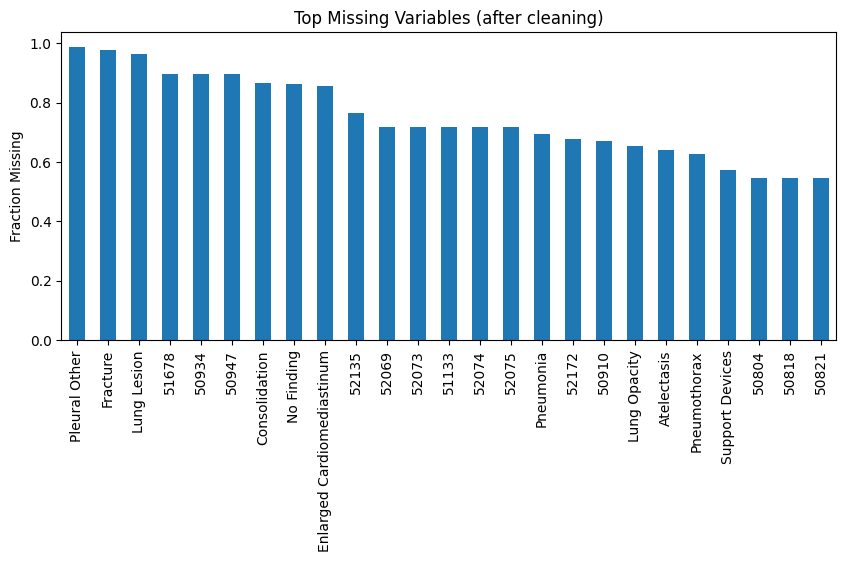

In [9]:
plt.figure(figsize=(10,4))
missing.head(25).plot(kind="bar")
plt.title("Top Missing Variables (after cleaning)")
plt.ylabel("Fraction Missing")
plt.show()


In [10]:
# Drop columns with >80% missing
missing_frac = df.isna().mean()

keep_cols = missing_frac[missing_frac < 0.8].index.tolist()

df = df[keep_cols]

print("Remaining shape after missingness filter:", df.shape)


Remaining shape after missingness filter: (11027, 67)


In [11]:
lab_cols = [c for c in df.columns if c.isdigit()]

cxr_cols = [
    "Atelectasis","Cardiomegaly","Consolidation","Edema",
    "Enlarged Cardiomediastinum","Fracture","Lung Lesion",
    "Lung Opacity","No Finding","Pleural Effusion",
    "Pleural Other","Pneumonia","Pneumothorax","Support Devices"
]
cxr_cols = [c for c in cxr_cols if c in df.columns]

demo_cols = ["age","gender","race","admission_type","admission_location","discharge_location"]

print("Labs:", len(lab_cols))
print("CXR labels:", cxr_cols)
print("Demographics:", demo_cols)


Labs: 47
CXR labels: ['Atelectasis', 'Cardiomegaly', 'Edema', 'Lung Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices']
Demographics: ['age', 'gender', 'race', 'admission_type', 'admission_location', 'discharge_location']


In [12]:
print("Mortality rate:", df["hospital_expire_flag"].mean())

df["los_days"].describe()

Mortality rate: 0.09195610773555818


,los_days
count,11027.000000
mean,9.343567
std,9.453830
min,0.002778
25%,4.061111
50%,6.787500
75%,11.197222
max,219.908333


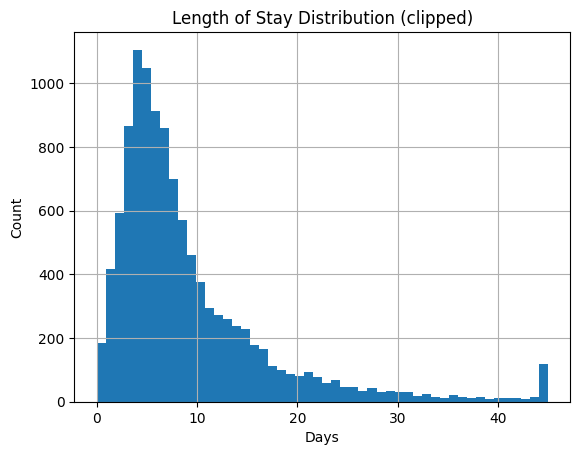

In [13]:
plt.figure()
df["los_days"].dropna().clip(upper=df["los_days"].quantile(0.99)).hist(bins=50)
plt.title("Length of Stay Distribution (clipped)")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

In [14]:
for col in ["gender","race","admission_type"]:
    if col in df.columns:
        display(df.groupby(col)["hospital_expire_flag"].mean().sort_values(ascending=False))


,hospital_expire_flag
gender,
M,0.094823
F,0.088573


,hospital_expire_flag
race,
UNABLE TO OBTAIN,0.405405
UNKNOWN,0.233387
ASIAN - KOREAN,0.157895
WHITE - EASTERN EUROPEAN,0.156250
HISPANIC/LATINO - SALVADORAN,0.142857
ASIAN,0.121739
BLACK/CARIBBEAN ISLAND,0.121622
WHITE - BRAZILIAN,0.120000
NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,0.105263


,hospital_expire_flag
admission_type,
EW EMER.,0.109941
OBSERVATION ADMIT,0.097419
URGENT,0.081178
DIRECT EMER.,0.046632
ELECTIVE,0.011628
SURGICAL SAME DAY ADMISSION,0.004739
AMBULATORY OBSERVATION,0.000000
EU OBSERVATION,0.000000
DIRECT OBSERVATION,0.000000


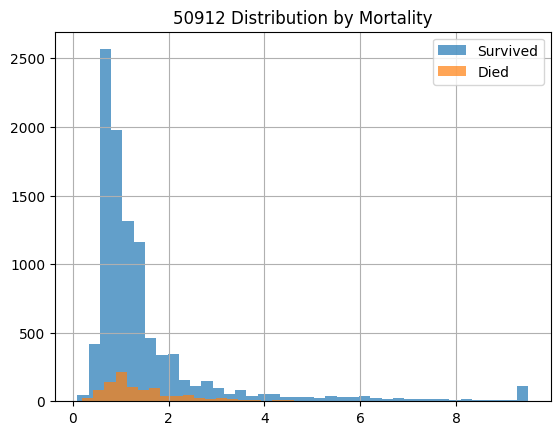

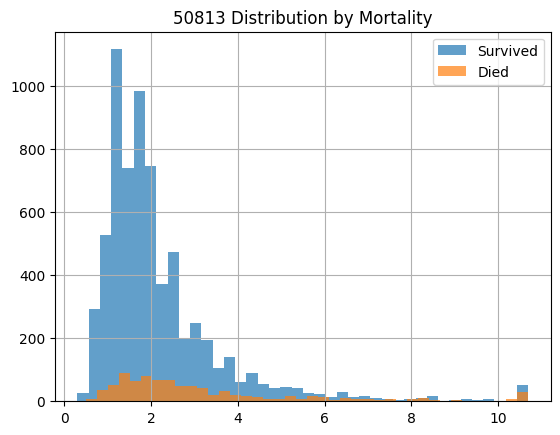

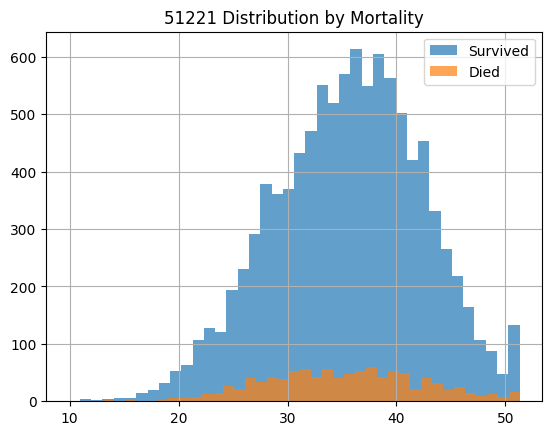

In [15]:
labs_to_plot = ["50912","50813","51221"]

for lab in labs_to_plot:
    if lab in df.columns:
        plt.figure()
        df[df["hospital_expire_flag"]==0][lab].dropna().clip(upper=df[lab].quantile(0.99)).hist(alpha=0.7, bins=40, label="Survived")
        df[df["hospital_expire_flag"]==1][lab].dropna().clip(upper=df[lab].quantile(0.99)).hist(alpha=0.7, bins=40, label="Died")
        plt.title(f"{lab} Distribution by Mortality")
        plt.legend()
        plt.show()


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ["age"] + lab_cols + cxr_cols
cluster_features = [c for c in cluster_features if c in df.columns]

Z = df[cluster_features].copy()

# Impute + scale
from sklearn.impute import SimpleImputer

Z_imp = SimpleImputer(strategy="median").fit_transform(Z)
Z_scaled = StandardScaler().fit_transform(Z_imp)

print("Clustering matrix:", Z_scaled.shape)

Clustering matrix: (11027, 56)


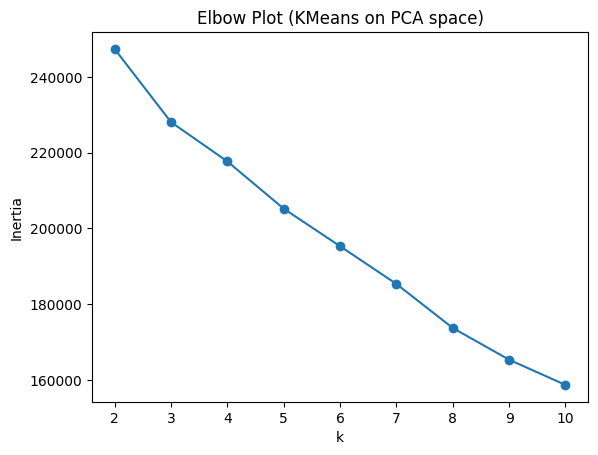

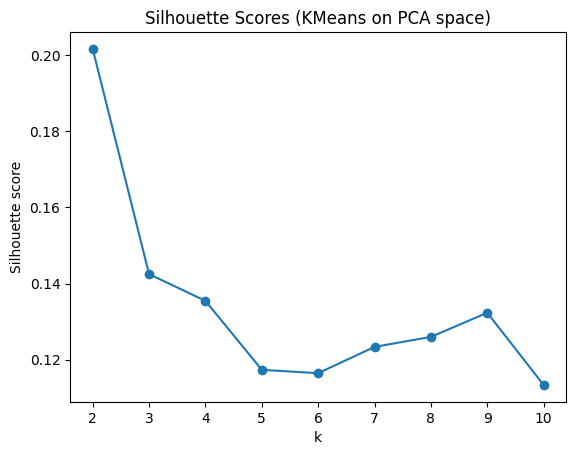

    k        inertia  silhouette
0   2  247365.184729    0.201596
1   3  228061.071305    0.142469
2   4  217672.460383    0.135461
3   5  205202.461022    0.117343
4   6  195290.202337    0.116467
5   7  185324.473579    0.123367
6   8  173695.146849    0.125991
7   9  165317.597010    0.132332
8  10  158660.873672    0.113385


In [47]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Recreate Z_scaled and Z_pca if needed
cluster_features = ["age"] + lab_cols + cxr_cols
cluster_features = [c for c in cluster_features if c in df.columns]
Z = df[cluster_features].copy()

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Z_imp = SimpleImputer(strategy="median").fit_transform(Z)
Z_scaled = StandardScaler().fit_transform(Z_imp)

pca = PCA(n_components=10, random_state=42)
Z_pca = pca.fit_transform(Z_scaled)

ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Z_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Z_pca, labels))

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Plot (KMeans on PCA space)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(list(ks), silhouettes, marker="o")
plt.title("Silhouette Scores (KMeans on PCA space)")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.show()

print(pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": silhouettes}))

In [45]:
# If df["cluster"] already exists from PCA+KMeans, great.
# If not, create cluster labels for k=4 here:

kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(Z_pca)

# Summary outcomes per cluster
cluster_summary = df.groupby("cluster").agg(
    n=("cluster", "count"),
    mortality=("hospital_expire_flag", "mean"),
    avg_los=("los_days", "mean"),
    avg_age=("age", "mean")
).sort_values("mortality", ascending=False)

display(cluster_summary)

# Median lab profiles
cluster_medians = df.groupby("cluster")[lab_cols].median()

# Compute how each cluster differs from the overall median
overall_median = df[lab_cols].median()
delta = cluster_medians.subtract(overall_median, axis=1)

# Show top 10 "most shifted" labs for each cluster (by absolute delta)
top_shift = {}
for c in cluster_medians.index:
    top_shift[c] = delta.loc[c].abs().sort_values(ascending=False).head(10)

# Pretty table for a chosen cluster (e.g., highest-mortality cluster)
high_cluster = cluster_summary.index[0]
profile = pd.DataFrame({
    "median_value": cluster_medians.loc[high_cluster],
    "delta_from_overall_median": delta.loc[high_cluster]
}).loc[top_shift[high_cluster].index]

display(profile)

,n,mortality,avg_los,avg_age
cluster,,,,
3,570,0.278947,13.397412,60.200000
0,1386,0.146465,10.679005,71.026696
2,3516,0.095848,9.795607,69.785267
1,5555,0.056706,8.308286,66.392259


,median_value,delta_from_overall_median
50910,417.5,291.5
50878,119.5,85.5
50931,179.0,55.0
50861,69.0,44.0
50821,73.0,-15.0
50802,-10.0,-10.0
50863,98.0,10.0
51265,225.0,9.0
50804,17.0,-8.0
50882,16.0,-8.0


In [18]:
df.groupby("cluster").agg(
    n=("cluster","count"),
    mortality=("hospital_expire_flag","mean"),
    avg_los=("los_days","mean"),
    avg_age=("age","mean")
)


,n,mortality,avg_los,avg_age
cluster,,,,
0,1212,0.217822,12.222440,65.870462
1,4102,0.104827,9.823129,70.920770
2,20,0.300000,17.153056,42.850000
3,5693,0.055155,8.357698,65.926928


In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)
Z_pca = pca.fit_transform(Z_scaled)

print("Explained variance:", pca.explained_variance_ratio_.sum())


Explained variance: 0.45121549472610156


In [20]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(Z_pca)

df["cluster"].value_counts()


,count
cluster,
1,5555
2,3516
0,1386
3,570


In [21]:
df.groupby("cluster").agg(
    n=("cluster","count"),
    mortality=("hospital_expire_flag","mean"),
    avg_los=("los_days","mean"),
    avg_age=("age","mean")
)


,n,mortality,avg_los,avg_age
cluster,,,,
0,1386,0.146465,10.679005,71.026696
1,5555,0.056706,8.308286,66.392259
2,3516,0.095848,9.795607,69.785267
3,570,0.278947,13.397412,60.200000


In [22]:
cluster_lab_profile = df.groupby("cluster")[lab_cols].median()
cluster_lab_profile.loc[[0,1,2]]


,51221,51265,50912,50971,51222,51301,51249,51279,51250,51248,51277,51006,50983,50902,50882,50868,50931,50960,50893,50970,51237,51274,51275,51146,51256,51254,51200,51244,52172,50861,50878,50813,50863,50885,50820,50862,50802,50821,50804,50818,52075,52073,52074,52069,51133,50910,52135
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,31.5,215.0,3.0,5.0,10.0,10.1,31.9,3.33,94.0,30.0,15.7,58.0,135.0,97.0,22.0,20.0,135.0,2.2,8.8,4.8,1.4,14.7,34.0,0.3,81.4,5.8,0.6,9.2,53.1,24.0,36.0,1.9,101.0,0.5,7.34,3.5,-2.0,63.0,24.0,41.0,8.835,0.04,0.77,0.03,0.90,128.0,0.6
1,39.6,219.0,1.0,4.1,13.1,9.8,33.1,4.36,91.0,30.4,13.7,18.0,138.0,101.0,25.0,16.0,124.0,1.9,8.9,3.4,1.1,12.0,30.5,0.4,77.9,5.5,0.8,13.4,45.2,25.0,30.0,1.8,79.0,0.5,7.38,3.9,0.0,100.0,26.0,43.0,7.520,0.07,0.70,0.04,1.36,135.0,0.5
2,30.0,210.0,1.0,4.2,9.6,8.9,31.9,3.28,92.0,29.4,15.9,22.0,138.0,102.0,25.0,15.0,119.0,1.9,8.5,3.4,1.3,13.9,31.5,0.3,76.9,6.0,1.0,12.8,53.0,22.0,33.0,1.6,97.0,0.5,7.39,3.2,0.0,100.5,26.0,42.0,6.735,0.07,0.68,0.03,1.09,81.5,0.6


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = df[lab_cols + ["age"]]
y = df["hospital_expire_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('sc', StandardScaler()),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [34]:
# Ensure indices are preserved
print(type(X_train), type(X_test))
print("X_test index example:", X_test.index[:5])

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>
X_test index example: Index([4773, 7302, 6132, 10879, 7929], dtype='int64')


In [35]:
import pandas as pd
import numpy as np

# Feature names
feature_names = X.columns

# Coefficients from the trained pipeline
lr_model = pipe.named_steps["lr"]
coefs = lr_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values("coef", ascending=False)

top_pos = coef_df.head(15).reset_index(drop=True)
top_neg = coef_df.tail(15).sort_values("coef").reset_index(drop=True)

display(top_pos)
display(top_neg)


,feature,coef
0,51274,1.191555
1,51279,1.064140
2,51222,0.602614
3,51248,0.566502
4,age,0.415172
5,50813,0.361224
6,51277,0.272422
7,50818,0.260842
8,50861,0.240020
9,50821,0.212605


,feature,coef
0,51221,-1.460968
1,51237,-1.146833
2,51249,-0.464737
3,50862,-0.348902
4,50912,-0.220302
5,51244,-0.219846
6,51200,-0.212494
7,50878,-0.195452
8,51146,-0.166075
9,51256,-0.111573


In [36]:
or_df = coef_df.copy()
or_df["odds_ratio_per_1sd"] = np.exp(or_df["coef"])
display(or_df.head(15))

,feature,coef,odds_ratio_per_1sd
21,51274,1.191555,3.292195
7,51279,1.064140,2.898346
4,51222,0.602614,1.826887
9,51248,0.566502,1.762092
47,age,0.415172,1.514632
31,50813,0.361224,1.435084
10,51277,0.272422,1.313140
39,50818,0.260842,1.298022
29,50861,0.240020,1.271275
37,50821,0.212605,1.236897


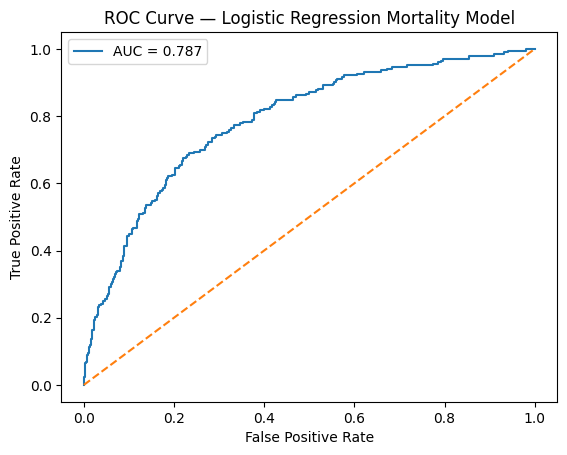

Logistic Regression Test AUC: 0.7871198128915001


In [37]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = pipe.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression Mortality Model")
plt.legend()
plt.show()

print("Logistic Regression Test AUC:", auc)


In [38]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_05 = (y_proba >= 0.50).astype(int)

cm = confusion_matrix(y_test, y_pred_05)
print("Confusion Matrix (threshold=0.50):\n", cm)

print("\nClassification Report (threshold=0.50):")
print(classification_report(y_test, y_pred_05, digits=3))

Confusion Matrix (threshold=0.50):
 [[1445  558]
 [  56  147]]

Classification Report (threshold=0.50):
              precision    recall  f1-score   support

           0      0.963     0.721     0.825      2003
           1      0.209     0.724     0.324       203

    accuracy                          0.722      2206
   macro avg      0.586     0.723     0.574      2206
weighted avg      0.893     0.722     0.779      2206



In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

target_recall = 0.80
idx = np.argmin(np.abs(recall - target_recall))
thr = thresholds[max(idx-1, 0)]  # thresholds has length-1 vs recall

y_pred_thr = (y_proba >= thr).astype(int)
print("Chosen threshold for ~80% recall:", thr)
print(confusion_matrix(y_test, y_pred_thr))
print(classification_report(y_test, y_pred_thr, digits=3))

Chosen threshold for ~80% recall: 0.4370963694895714
[[1247  756]
 [  40  163]]
              precision    recall  f1-score   support

           0      0.969     0.623     0.758      2003
           1      0.177     0.803     0.291       203

    accuracy                          0.639      2206
   macro avg      0.573     0.713     0.524      2206
weighted avg      0.896     0.639     0.715      2206



Random Forest Test AUC: 0.8050854752354227


,feature,importance
0,50813,0.053652
1,age,0.041041
2,50862,0.032705
3,51277,0.031925
4,51244,0.031306
5,51301,0.030164
6,51274,0.028256
7,50878,0.027118
8,51275,0.026942
9,50931,0.025873


<Figure size 800x500 with 0 Axes>

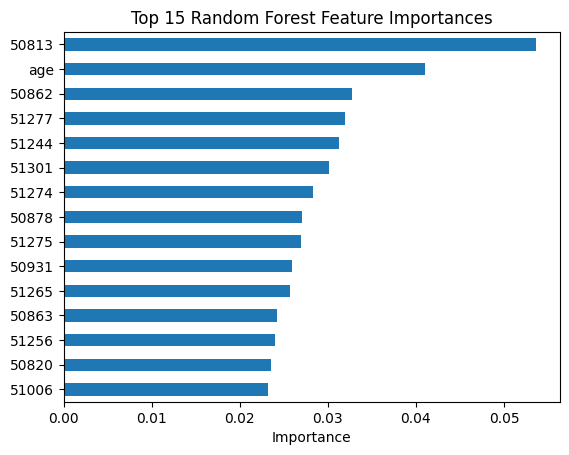

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

rf = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
print("Random Forest Test AUC:", rf_auc)

rf_model = rf.named_steps["rf"]
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

rf_top15 = rf_importance.head(15).reset_index()
rf_top15.columns = ["feature", "importance"]
display(rf_top15)

# Plot top 15 importances
plt.figure(figsize=(8, 5))
rf_top15.sort_values("importance").plot(kind="barh", x="feature", y="importance", legend=False)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

In [41]:
# Merge LR and RF rankings
lr_rank = coef_df.copy()
lr_rank["abs_coef"] = lr_rank["coef"].abs()
lr_rank = lr_rank.sort_values("abs_coef", ascending=False).head(20)[["feature", "coef", "abs_coef"]]

rf_rank = rf_importance.reset_index()
rf_rank.columns = ["feature", "rf_importance"]
rf_rank = rf_rank.head(20)

combo = lr_rank.merge(rf_rank, on="feature", how="outer").sort_values(
    by=["rf_importance", "abs_coef"], ascending=False
)

display(combo.head(25))

,feature,coef,abs_coef,rf_importance
1,50813,0.361224,0.361224,0.053652
29,age,0.415172,0.415172,0.041041
6,50862,-0.348902,0.348902,0.032705
26,51277,0.272422,0.272422,0.031925
19,51244,-0.219846,0.219846,0.031306
28,51301,NaN,NaN,0.030164
24,51274,1.191555,1.191555,0.028256
9,50878,-0.195452,0.195452,0.027118
25,51275,NaN,NaN,0.026942
12,50931,NaN,NaN,0.025873


In [42]:
from sklearn.metrics import roc_auc_score

def auc_by_group(model, X_subset, y_subset, group_series, min_n=30):
    rows = []
    for g in sorted(group_series.dropna().unique()):
        idx = group_series == g
        n = idx.sum()
        if n < min_n:
            continue
        proba = model.predict_proba(X_subset.loc[idx])[:, 1]
        auc = roc_auc_score(y_subset.loc[idx], proba)
        rows.append([g, n, auc])
    return pd.DataFrame(rows, columns=["group", "n", "auc"]).sort_values("auc", ascending=False)

# Gender
gender_auc = auc_by_group(
    pipe,
    X_test,
    y_test,
    df.loc[X_test.index, "gender"],
    min_n=30
)
display(gender_auc)

# Race (require more samples)
race_auc = auc_by_group(
    pipe,
    X_test,
    y_test,
    df.loc[X_test.index, "race"],
    min_n=100
)
display(race_auc)

,group,n,auc
1,M,1196,0.802221
0,F,1010,0.768430


,group,n,auc
2,WHITE,1417,0.776343
0,BLACK/AFRICAN AMERICAN,248,0.756031
1,UNKNOWN,123,0.755686


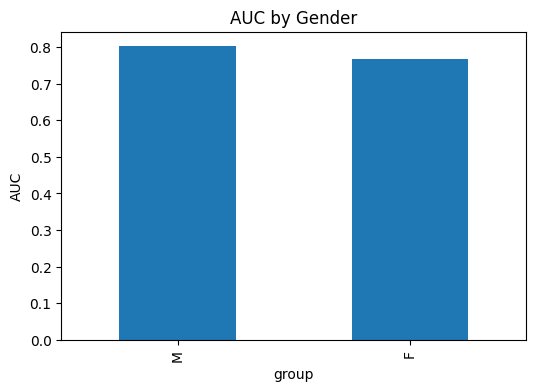

In [43]:
plt.figure(figsize=(6,4))
gender_auc.set_index("group")["auc"].plot(kind="bar")
plt.title("AUC by Gender")
plt.ylabel("AUC")
plt.show()


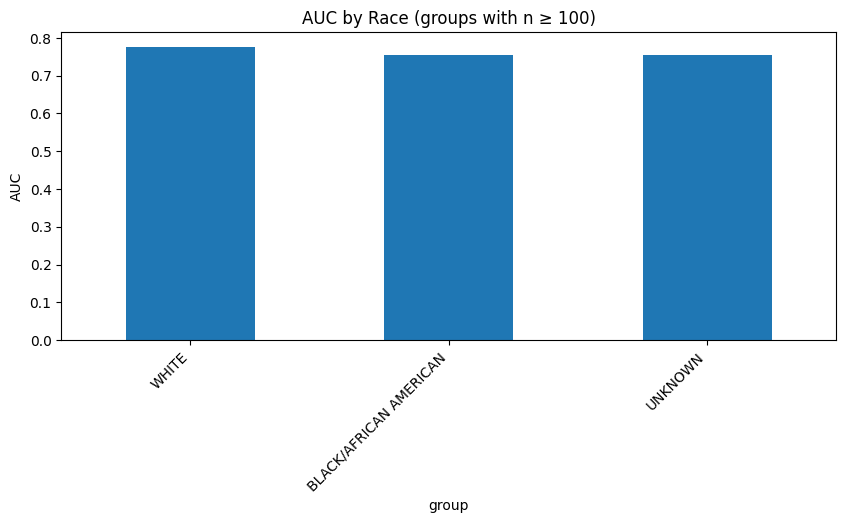

In [44]:
plt.figure(figsize=(10,4))
race_auc.set_index("group")["auc"].plot(kind="bar")
plt.title("AUC by Race (groups with n ≥ 100)")
plt.ylabel("AUC")
plt.xticks(rotation=45, ha="right")
plt.show()


In [46]:
lab_map = {
    "50813": "Lactate",
    "50912": "Creatinine",
    "51006": "Blood Urea Nitrogen (BUN)",
    "50820": "pH",
    "50868": "Anion Gap",
    "51301": "White Blood Cell Count (WBC)",
    "51274": "Prothrombin Time (PT)",
    "51275": "Partial Thromboplastin Time (PTT)",
    "50862": "Albumin",
    "50878": "AST",
    "51277": "RDW",
    "51244": "Lymphocytes",
    "51256": "Neutrophils",
    "50931": "Glucose"
}

# Apply mapping to LR + RF tables
top_pos_named = top_pos.copy()
top_pos_named["name"] = top_pos_named["feature"].astype(str).map(lab_map).fillna(top_pos_named["feature"])
display(top_pos_named)

rf_top15_named = rf_top15.copy()
rf_top15_named["name"] = rf_top15_named["feature"].astype(str).map(lab_map).fillna(rf_top15_named["feature"])
display(rf_top15_named)

,feature,coef,name
0,51274,1.191555,Prothrombin Time (PT)
1,51279,1.064140,51279
2,51222,0.602614,51222
3,51248,0.566502,51248
4,age,0.415172,age
5,50813,0.361224,Lactate
6,51277,0.272422,RDW
7,50818,0.260842,50818
8,50861,0.240020,50861
9,50821,0.212605,50821


,feature,importance,name
0,50813,0.053652,Lactate
1,age,0.041041,age
2,50862,0.032705,Albumin
3,51277,0.031925,RDW
4,51244,0.031306,Lymphocytes
5,51301,0.030164,White Blood Cell Count (WBC)
6,51274,0.028256,Prothrombin Time (PT)
7,50878,0.027118,AST
8,51275,0.026942,Partial Thromboplastin Time (PTT)
9,50931,0.025873,Glucose
